In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('wine-clustering.csv')

In [3]:
df.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


# Find the Optimal Number of Clusters

In [4]:
from sklearn.cluster import KMeans

In [5]:
inertia = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(df)
    inertia.append(kmeans.inertia_)

In [6]:
inertia

[17592296.383508474,
 4545746.292099378,
 2370689.6867829696,
 1551101.2654500774,
 988245.3238000525,
 647326.0020260852,
 414752.87383925036,
 323211.55263465457,
 283773.52948989684,
 230705.9788086923]

In [7]:
import  matplotlib.pyplot as plt

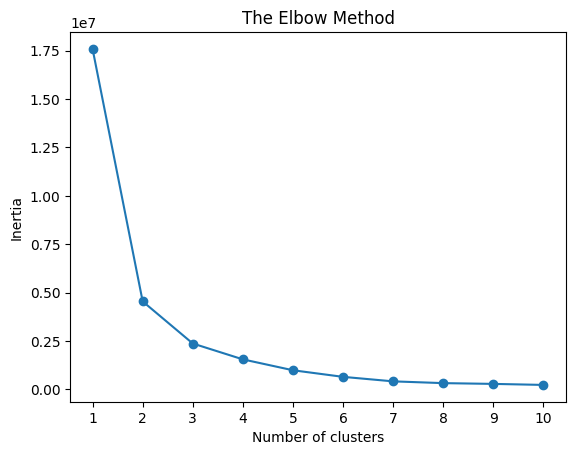

In [8]:
plt.plot(range(1, 11), inertia, marker='o')
plt.xticks(range(1, 11))
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

In [9]:
# Optimal Number of Clusters is 3

In [10]:
kmeans = KMeans(n_clusters=3, random_state=0)

In [11]:
kmeans.fit(df)

KMeans(n_clusters=3, random_state=0)

In [12]:
labels = kmeans.labels_

In [13]:
labels

array([1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2,
       1, 1, 2, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 2, 2, 1, 1, 2,
       2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 2, 0, 2, 0, 0, 2,
       0, 0, 2, 2, 2, 0, 0, 1, 2, 0, 0, 0, 2, 0, 0, 2, 2, 0, 0, 0, 0, 0,
       2, 2, 0, 0, 0, 0, 0, 2, 2, 0, 2, 0, 2, 0, 0, 0, 2, 0, 0, 0, 0, 2,
       0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0,
       0, 2, 2, 2, 2, 0, 0, 0, 2, 2, 0, 0, 2, 2, 0, 2, 2, 0, 0, 0, 0, 2,
       2, 2, 0, 2, 2, 2, 0, 2, 0, 2, 2, 0, 2, 2, 2, 2, 0, 0, 2, 2, 2, 2,
       2, 0], dtype=int32)

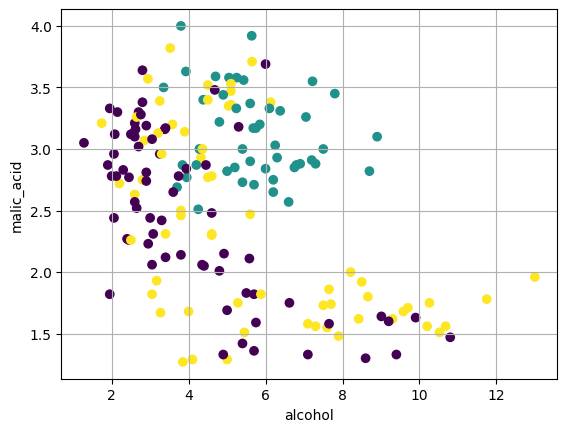

In [14]:
plt.scatter(df.loc[:,'Color_Intensity'], df.loc[:,'OD280'], c=labels)
plt.xlabel('alcohol')
plt.ylabel('malic_acid')
plt.grid(True)
plt.show()

# User Interface

In [15]:
while True:

    alcohol = float(input("Enter Alcohol: "))
    malic_acid = float(input("Enter Malic Acid: "))
    Ash = float(input("Enter Ash: "))
    Ash_Alcanity = float(input("Enter Ash_Alcanity: "))
    Magnesium = float(input("Enter Magnesium: "))
    Total_Phenols = float(input("Enter Total_Phenols: "))
    Flavanoids = float(input("Enter Flavanoids: "))
    Nonflavanoid_Phenols = float(input("Enter Nonflavanoid_Phenols: "))
    Proanthocyanins = float(input("Enter Proanthocyanins: "))
    Color_Intensity = float(input("Enter Color_Intensity: "))
    Hue = float(input("Enter Hue: "))
    OD280 = float(input("Enter OD280: "))
    Proline = float(input("Enter Proline: "))


    user_data = [[alcohol,
                  malic_acid,
                  Ash,
                  Ash_Alcanity,
                  Magnesium,
                  Total_Phenols,
                  Flavanoids,
                  Nonflavanoid_Phenols,
                  Proanthocyanins,
                  Color_Intensity,
                  Hue,
                  OD280,
                  Proline
                  ]]

    cluster = kmeans.predict(user_data)[0]
    print("This data point belongs to Cluster:", cluster)

    again = input("Enter another? (Y/N): ").lower()
    if again == 'n':
        break

Enter Alcohol: 14.23
Enter Malic Acid: 2.23
Enter Ash: 2.21
Enter Ash_Alcanity: 19.3
Enter Magnesium: 89
Enter Total_Phenols: 2.4
Enter Flavanoids: 2.19
Enter Nonflavanoid_Phenols: 0.23
Enter Proanthocyanins: 1.13
Enter Color_Intensity: 4.32
Enter Hue: 0.92
Enter OD280: 2.87
Enter Proline: 938


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


This data point belongs to Cluster: 2
Enter another? (Y/N): n


In [16]:
import joblib

In [17]:
joblib.dump(kmeans, 'Clustering.pkl')

['Clustering.pkl']